# FNN网络拟合一元函数

In [106]:
import os
os.environ['CUDA_VISIBLE_DEVICES']='0'
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

import time
import scipy.io as io
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

torch.manual_seed(1234)
np.random.seed(1234)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('running on: %s'%(device))


running on: cuda


## 构建FNN网络

In [107]:
## ----构建FNN网络----
class FNN(nn.Module):
    def __init__(self, layers, actn = 'tanh'):
        super().__init__()
        L = len(layers)


        self.linear = nn.ModuleList([nn.Linear(layers[l-1], layers[l]) for l in range(1, L)])

        # 激活函数
        if actn == 'relu':
            actn = nn.ReLU()
        elif actn == 'tanh':
            actn = nn.Tanh()
        elif actn == 'sigmoid':
            actn = nn.Sigmoid()
        self.activation = actn

    def forward(self, inputs):
        x = inputs
        for linear in self.linear[:-1]:
            x = self.activation(linear(x))
        x = self.linear[-1](x)
        return x


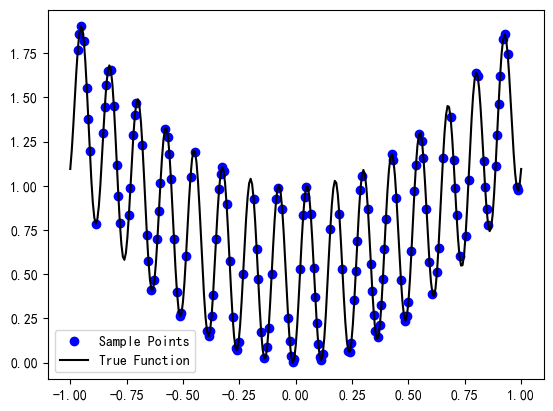

In [108]:


# 目标函数
def target_func(x):
    return x**2 + np.sin(8*np.pi*x+np.pi/10)**2

# 生成数据
def generate_data(num_train=150): # 样本点数
    num_test = 301 # 全集与样本点数
    x = np.linspace(-1, 1, num_test).reshape((-1, 1))
    y = target_func(x)
    idx = np.random.choice(num_test, num_train,  replace=False)

    #训练点数
    x_train, y_train = x[idx], y[idx]
    return x_train, y_train, x, y

# 训练点数
num_train = 150
# 数据集
x_train, y_train, x_ref, y_ref = generate_data(num_train)

plt.figure()
matplotlib.rcParams['axes.unicode_minus'] =False
# plt.rcParams['font.sans-serif']=['KaiTi'] 
plt.plot(x_train, y_train, 'bo',label='Sample Points')
plt.plot(x_ref, y_ref, 'k-',label='True Function')
plt.legend()
plt.show()

## 模型训练

In [109]:
## ----模型训练---

# 训练模型
def train_model(x_train, y_train, layers=[1, 50, 50, 1], actn='tanh', epochs=25000):
    # 网络模型
    model = FNN(layers, actn)
    model = model.to(device)
    print(model.state_dict()['linear.2.weight'].shape)

    x_train, y_train = torch.tensor(x_train, dtype=torch.float32), \
        torch.tensor(y_train, dtype=torch.float32)
    x_train, y_train = x_train.to(device), y_train.to(device)


    opt = torch.optim.Adam(model.parameters(), lr=1.0e-3)
    loss_fn = nn.MSELoss()

    loss_history = []

    for epoch in range(1,epochs+1):
        y_pred = model(x_train)
        loss = loss_fn(y_pred, y_train)

        opt.zero_grad() #梯度清零
        loss.backward()
        opt.step()
        loss_history.append(loss.item())


        if epoch%1000 == 0:
            print('Steps: %d, loss: %.3e'%(epoch, loss.item()))
    loss_history = np.array(loss_history).reshape(-1,1)
    return model.cpu(),loss_history

#  网络结构层数与深度
layers = [1] + [100]*3 + [1]
# 激活函数
actn = 'tanh'
# 训练轮次
epochs = 20000


model, loss = train_model(x_train, y_train, layers, actn, epochs)



torch.Size([100, 100])
Steps: 1000, loss: 1.181e-01
Steps: 2000, loss: 1.180e-01
Steps: 3000, loss: 1.179e-01
Steps: 4000, loss: 1.165e-01
Steps: 5000, loss: 1.096e-01
Steps: 6000, loss: 1.027e-01
Steps: 7000, loss: 1.011e-01
Steps: 8000, loss: 9.473e-02
Steps: 9000, loss: 8.419e-02
Steps: 10000, loss: 6.890e-02
Steps: 11000, loss: 5.782e-02
Steps: 12000, loss: 3.903e-02
Steps: 13000, loss: 3.909e-02
Steps: 14000, loss: 2.322e-02
Steps: 15000, loss: 2.765e-02
Steps: 16000, loss: 4.518e-03
Steps: 17000, loss: 7.951e-04
Steps: 18000, loss: 3.510e-04
Steps: 19000, loss: 2.231e-04
Steps: 20000, loss: 1.660e-04


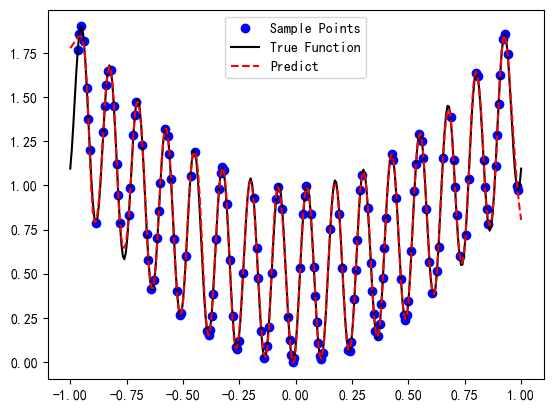

In [110]:
x_ref = torch.tensor(x_ref, dtype=torch.float32)
y_test = model(x_ref)

plt.figure()
plt.rcParams['font.sans-serif']=['KaiTi'] 
plt.plot(x_train, y_train, 'bo',label='Sample Points')
plt.plot(x_ref, y_ref, 'k-',label='True Function')

plt.plot(x_ref, y_test.detach().numpy(), 'r--',label="Predict")
plt.legend()
plt.show()

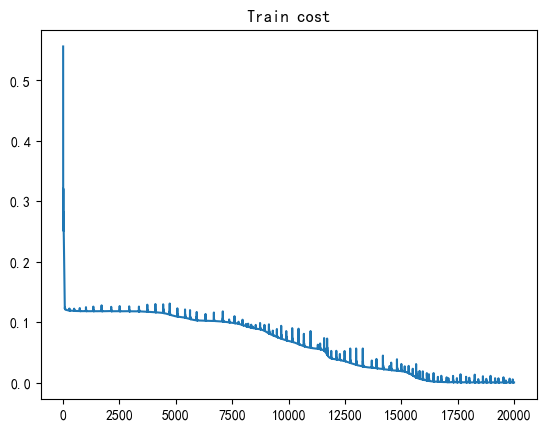

In [111]:
nsum = np.array([i+1 for i in range(epochs)]).reshape(-1,1)

plt.figure()
plt.plot(nsum, loss ,label="Train cost")
plt.title('Train cost')
plt.show()

In [112]:
## 模型评估

def evaluate(model):

    x_test=np.linspace(-1,1,301).reshape((-1,1))
    y_true=target_func(x_test)

    x_test_tensor=torch.tensor(x_test, dtype=torch.float32)

    with torch.no_grad():
        y_pred=model.cpu()(x_test_tensor)

    mse=mean_squared_error(y_true,y_pred)
    mae=mean_absolute_error(y_true,y_pred)

    return x_test, y_true, y_pred, mse, mae
 
test = evaluate(model)
print(dict(zip(['MSE','MAE'],test[3:])))

{'MSE': 0.004608729565307535, 'MAE': 0.02108650952102996}


In [113]:
def plot_result(x_true,y_true,y_pred,title):
    plt.figure(figsize=(6,4))
    plt.plot(x_true,y_true,label="True Function")
    plt.plot(x_true,y_pred,label="Prediction")
    plt.legend()
    plt.title(title)
    plt.show()


def plot_loss(loss_dict, title):
    plt.figure()
    for key, loss in loss_dict.items():
        plt.plot(loss, label=key)

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.show()


## 问题1：训练点数影响

torch.Size([1, 50])
Steps: 1000, loss: 8.100e-02
Steps: 2000, loss: 1.252e-03
Steps: 3000, loss: 7.306e-04
Steps: 4000, loss: 5.023e-04
Steps: 5000, loss: 2.492e-04
Steps: 6000, loss: 3.211e-05
Steps: 7000, loss: 2.517e-05
Steps: 8000, loss: 2.348e-06
Steps: 9000, loss: 7.804e-05
Steps: 10000, loss: 1.181e-04
Steps: 11000, loss: 6.660e-06
Steps: 12000, loss: 8.595e-09
Steps: 13000, loss: 1.342e-09
Steps: 14000, loss: 1.104e-09
Steps: 15000, loss: 4.235e-07
Steps: 16000, loss: 9.472e-08
Steps: 17000, loss: 8.743e-07
Steps: 18000, loss: 3.683e-07
Steps: 19000, loss: 5.402e-09
Steps: 20000, loss: 2.218e-09
Steps: 21000, loss: 1.417e-09
Steps: 22000, loss: 1.482e-08
Steps: 23000, loss: 8.976e-06
Steps: 24000, loss: 4.886e-05
Steps: 25000, loss: 6.768e-10


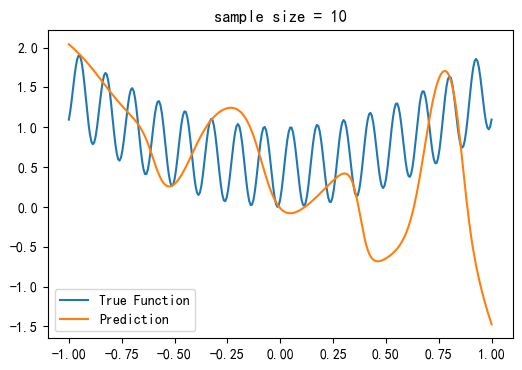

torch.Size([1, 50])
Steps: 1000, loss: 8.130e-02
Steps: 2000, loss: 4.035e-02
Steps: 3000, loss: 2.252e-02
Steps: 4000, loss: 1.648e-02
Steps: 5000, loss: 1.316e-02
Steps: 6000, loss: 2.366e-03
Steps: 7000, loss: 4.716e-04
Steps: 8000, loss: 2.561e-04
Steps: 9000, loss: 1.036e-04
Steps: 10000, loss: 2.391e-05
Steps: 11000, loss: 6.966e-06
Steps: 12000, loss: 5.863e-05
Steps: 13000, loss: 1.418e-04
Steps: 14000, loss: 1.390e-06
Steps: 15000, loss: 8.648e-07
Steps: 16000, loss: 5.440e-07
Steps: 17000, loss: 4.849e-07
Steps: 18000, loss: 2.305e-07
Steps: 19000, loss: 2.298e-05
Steps: 20000, loss: 1.095e-07
Steps: 21000, loss: 9.334e-07
Steps: 22000, loss: 5.742e-08
Steps: 23000, loss: 4.320e-08
Steps: 24000, loss: 1.054e-05
Steps: 25000, loss: 4.790e-06


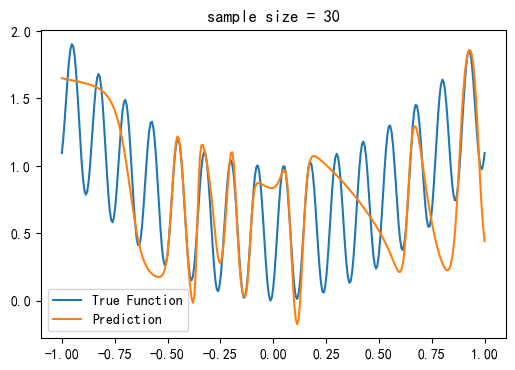

torch.Size([1, 50])
Steps: 1000, loss: 1.199e-01
Steps: 2000, loss: 1.143e-01
Steps: 3000, loss: 9.895e-02
Steps: 4000, loss: 5.955e-02
Steps: 5000, loss: 4.147e-02
Steps: 6000, loss: 9.788e-03
Steps: 7000, loss: 3.196e-04
Steps: 8000, loss: 1.553e-04
Steps: 9000, loss: 8.466e-05
Steps: 10000, loss: 5.316e-05
Steps: 11000, loss: 3.187e-05
Steps: 12000, loss: 2.308e-05
Steps: 13000, loss: 2.291e-05
Steps: 14000, loss: 1.602e-05
Steps: 15000, loss: 1.714e-05
Steps: 16000, loss: 1.309e-05
Steps: 17000, loss: 1.224e-05
Steps: 18000, loss: 1.044e-05
Steps: 19000, loss: 9.082e-06
Steps: 20000, loss: 7.790e-06
Steps: 21000, loss: 7.239e-06
Steps: 22000, loss: 5.692e-06
Steps: 23000, loss: 4.984e-06
Steps: 24000, loss: 4.196e-06
Steps: 25000, loss: 3.997e-06


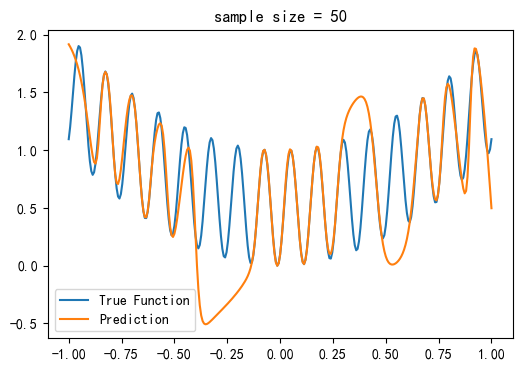

torch.Size([1, 50])
Steps: 1000, loss: 1.178e-01
Steps: 2000, loss: 1.150e-01
Steps: 3000, loss: 1.056e-01
Steps: 4000, loss: 6.520e-02
Steps: 5000, loss: 4.933e-02
Steps: 6000, loss: 4.565e-02
Steps: 7000, loss: 3.410e-02
Steps: 8000, loss: 2.580e-02
Steps: 9000, loss: 2.200e-02
Steps: 10000, loss: 1.941e-02
Steps: 11000, loss: 1.481e-02
Steps: 12000, loss: 1.068e-02
Steps: 13000, loss: 8.761e-03
Steps: 14000, loss: 7.365e-03
Steps: 15000, loss: 3.715e-03
Steps: 16000, loss: 2.739e-03
Steps: 17000, loss: 1.510e-03
Steps: 18000, loss: 2.129e-04
Steps: 19000, loss: 1.487e-04
Steps: 20000, loss: 1.141e-04
Steps: 21000, loss: 8.817e-05
Steps: 22000, loss: 6.954e-05
Steps: 23000, loss: 5.716e-05
Steps: 24000, loss: 4.642e-05
Steps: 25000, loss: 1.052e-04


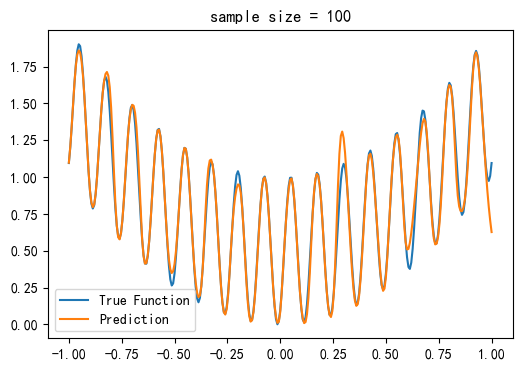

torch.Size([1, 50])
Steps: 1000, loss: 1.177e-01
Steps: 2000, loss: 1.176e-01
Steps: 3000, loss: 1.174e-01
Steps: 4000, loss: 1.056e-01
Steps: 5000, loss: 9.160e-02
Steps: 6000, loss: 7.608e-02
Steps: 7000, loss: 7.287e-02
Steps: 8000, loss: 6.122e-02
Steps: 9000, loss: 5.829e-02
Steps: 10000, loss: 4.764e-02
Steps: 11000, loss: 3.671e-02
Steps: 12000, loss: 2.731e-02
Steps: 13000, loss: 2.265e-02
Steps: 14000, loss: 1.660e-02
Steps: 15000, loss: 1.580e-02
Steps: 16000, loss: 5.351e-04
Steps: 17000, loss: 1.746e-04
Steps: 18000, loss: 1.001e-04
Steps: 19000, loss: 6.618e-05
Steps: 20000, loss: 1.371e-04
Steps: 21000, loss: 4.003e-05
Steps: 22000, loss: 3.400e-05
Steps: 23000, loss: 3.032e-05
Steps: 24000, loss: 4.208e-05
Steps: 25000, loss: 5.742e-05


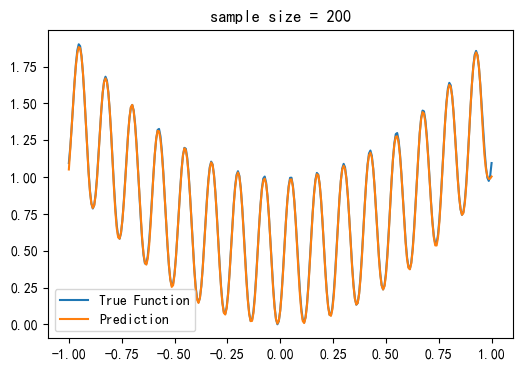

[[1.00000000e+01 7.81191167e-01 6.53725366e-01]
 [3.00000000e+01 1.96696184e-01 3.01814748e-01]
 [5.00000000e+01 2.24238186e-01 2.56402178e-01]
 [1.00000000e+02 4.21863506e-03 3.22526972e-02]
 [2.00000000e+02 1.43505707e-04 8.92832820e-03]]


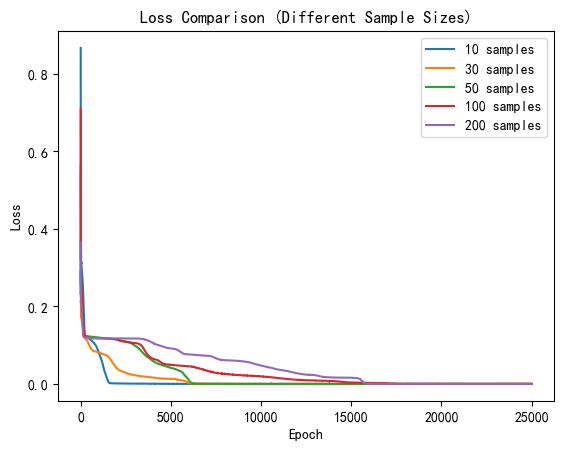

In [114]:
## ----训练点数影响----
sample_sizes = [10, 30, 50, 100, 200]

results_q1 = []
loss_dict_q1 = {}

for n in sample_sizes:
    x_train_q1, y_train_q1, x_ref_q1, y_ref_q1 = generate_data(n)
    model_q1 ,loss_q1= train_model(x_train_q1, y_train_q1)

    x_test_q1, y_true_q1, y_pred_q1, mse_q1, mae_q1 = evaluate(model_q1)
    results_q1.append([n, mse_q1, mae_q1])

    loss_dict_q1[str(n)+' samples']=loss_q1
    
    plot_result(x_test_q1, y_true_q1, y_pred_q1,f"sample size = {n}")
print(np.array(results_q1))

plot_loss(loss_dict_q1, title='Loss Comparison (Different Sample Sizes)')

## 问题2：网络结构（层数与深度）影响

[1, 20, 20, 1]
torch.Size([1, 20])
Steps: 1000, loss: 1.147e-01
Steps: 2000, loss: 1.144e-01
Steps: 3000, loss: 1.142e-01
Steps: 4000, loss: 1.142e-01
Steps: 5000, loss: 1.141e-01
Steps: 6000, loss: 1.135e-01
Steps: 7000, loss: 1.107e-01
Steps: 8000, loss: 1.075e-01
Steps: 9000, loss: 1.005e-01
Steps: 10000, loss: 9.877e-02
Steps: 11000, loss: 9.165e-02
Steps: 12000, loss: 8.725e-02
Steps: 13000, loss: 8.106e-02
Steps: 14000, loss: 7.735e-02
Steps: 15000, loss: 7.382e-02
Steps: 16000, loss: 7.136e-02
Steps: 17000, loss: 6.740e-02
Steps: 18000, loss: 6.289e-02
Steps: 19000, loss: 5.721e-02
Steps: 20000, loss: 5.469e-02
Steps: 21000, loss: 4.638e-02
Steps: 22000, loss: 3.845e-02
Steps: 23000, loss: 3.620e-02
Steps: 24000, loss: 3.518e-02
Steps: 25000, loss: 3.331e-02
structure: [20, 20] MSE: 0.05733005185840444 MAE: 0.15017831649968125


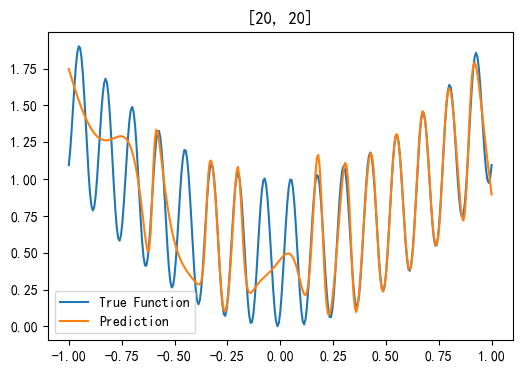

[1, 20, 20, 20, 1]
torch.Size([20, 20])
Steps: 1000, loss: 1.175e-01
Steps: 2000, loss: 1.165e-01
Steps: 3000, loss: 1.165e-01
Steps: 4000, loss: 1.165e-01
Steps: 5000, loss: 1.165e-01
Steps: 6000, loss: 1.164e-01
Steps: 7000, loss: 1.164e-01
Steps: 8000, loss: 1.158e-01
Steps: 9000, loss: 1.106e-01
Steps: 10000, loss: 9.407e-02
Steps: 11000, loss: 8.509e-02
Steps: 12000, loss: 8.113e-02
Steps: 13000, loss: 7.778e-02
Steps: 14000, loss: 7.554e-02
Steps: 15000, loss: 7.334e-02
Steps: 16000, loss: 7.037e-02
Steps: 17000, loss: 6.947e-02
Steps: 18000, loss: 6.883e-02
Steps: 19000, loss: 6.780e-02
Steps: 20000, loss: 6.503e-02
Steps: 21000, loss: 6.095e-02
Steps: 22000, loss: 5.668e-02
Steps: 23000, loss: 5.377e-02
Steps: 24000, loss: 5.152e-02
Steps: 25000, loss: 4.993e-02
structure: [20, 20, 20] MSE: 0.07888964562478723 MAE: 0.2026496781108218


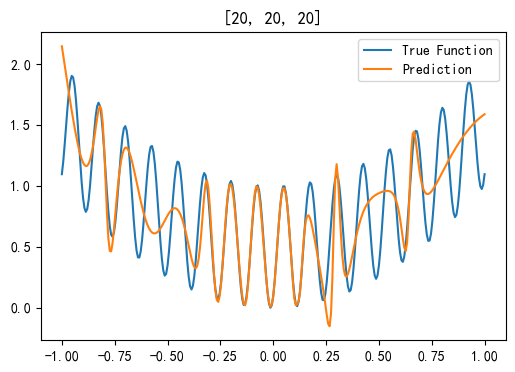

[1, 50, 50, 1]
torch.Size([1, 50])
Steps: 1000, loss: 1.138e-01
Steps: 2000, loss: 1.129e-01
Steps: 3000, loss: 1.089e-01
Steps: 4000, loss: 1.082e-01
Steps: 5000, loss: 1.049e-01
Steps: 6000, loss: 9.603e-02
Steps: 7000, loss: 8.606e-02
Steps: 8000, loss: 6.646e-02
Steps: 9000, loss: 5.434e-02
Steps: 10000, loss: 4.249e-02
Steps: 11000, loss: 3.951e-02
Steps: 12000, loss: 3.750e-02
Steps: 13000, loss: 3.429e-02
Steps: 14000, loss: 3.246e-02
Steps: 15000, loss: 2.698e-02
Steps: 16000, loss: 2.485e-02
Steps: 17000, loss: 2.095e-02
Steps: 18000, loss: 1.704e-02
Steps: 19000, loss: 1.666e-02
Steps: 20000, loss: 1.257e-02
Steps: 21000, loss: 5.985e-04
Steps: 22000, loss: 3.971e-04
Steps: 23000, loss: 3.032e-04
Steps: 24000, loss: 2.164e-04
Steps: 25000, loss: 1.368e-04
structure: [50, 50] MSE: 0.0004527617622281006 MAE: 0.011518179617566873


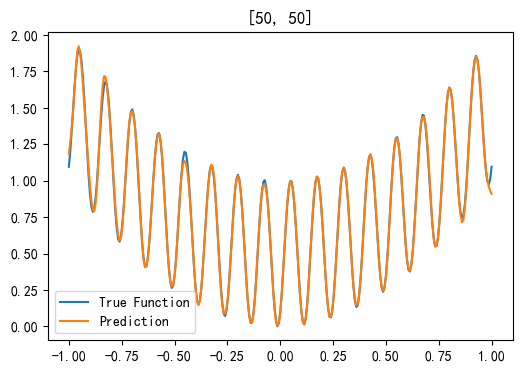

[1, 50, 50, 50, 1]
torch.Size([50, 50])
Steps: 1000, loss: 1.290e-01
Steps: 2000, loss: 1.273e-01
Steps: 3000, loss: 1.258e-01
Steps: 4000, loss: 1.117e-01
Steps: 5000, loss: 9.779e-02
Steps: 6000, loss: 9.111e-02
Steps: 7000, loss: 8.386e-02
Steps: 8000, loss: 6.989e-02
Steps: 9000, loss: 6.468e-02
Steps: 10000, loss: 5.881e-02
Steps: 11000, loss: 4.871e-02
Steps: 12000, loss: 4.245e-02
Steps: 13000, loss: 4.089e-02
Steps: 14000, loss: 3.886e-02
Steps: 15000, loss: 3.622e-02
Steps: 16000, loss: 3.150e-02
Steps: 17000, loss: 2.929e-02
Steps: 18000, loss: 2.840e-02
Steps: 19000, loss: 2.379e-02
Steps: 20000, loss: 1.932e-02
Steps: 21000, loss: 1.751e-02
Steps: 22000, loss: 1.529e-02
Steps: 23000, loss: 1.349e-02
Steps: 24000, loss: 1.126e-02
Steps: 25000, loss: 1.062e-02
structure: [50, 50, 50] MSE: 0.0129847678315006 MAE: 0.05042044553203294


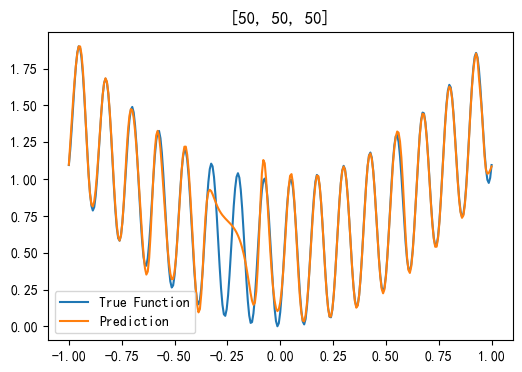

[1, 50, 50, 50, 50, 1]
torch.Size([50, 50])
Steps: 1000, loss: 1.124e-01
Steps: 2000, loss: 1.080e-01
Steps: 3000, loss: 1.016e-01
Steps: 4000, loss: 9.977e-02
Steps: 5000, loss: 9.298e-02
Steps: 6000, loss: 8.503e-02
Steps: 7000, loss: 7.523e-02
Steps: 8000, loss: 7.095e-02
Steps: 9000, loss: 6.927e-02
Steps: 10000, loss: 6.809e-02
Steps: 11000, loss: 6.602e-02
Steps: 12000, loss: 6.272e-02
Steps: 13000, loss: 6.147e-02
Steps: 14000, loss: 7.106e-02
Steps: 15000, loss: 5.988e-02
Steps: 16000, loss: 5.912e-02
Steps: 17000, loss: 5.848e-02
Steps: 18000, loss: 5.798e-02
Steps: 19000, loss: 5.882e-02
Steps: 20000, loss: 5.752e-02
Steps: 21000, loss: 5.738e-02
Steps: 22000, loss: 5.723e-02
Steps: 23000, loss: 5.709e-02
Steps: 24000, loss: 5.683e-02
Steps: 25000, loss: 5.755e-02
structure: [50, 50, 50, 50] MSE: 0.07688503293970353 MAE: 0.21024785250458145


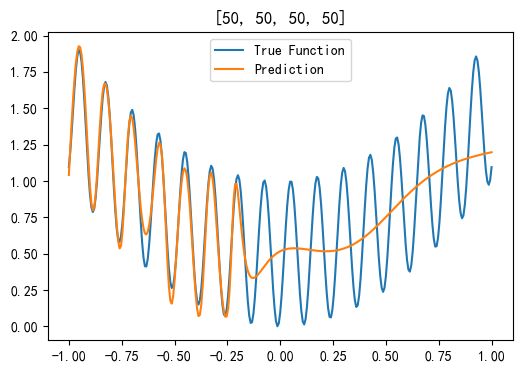

[1, 100, 100, 1]
torch.Size([1, 100])
Steps: 1000, loss: 1.229e-01
Steps: 2000, loss: 1.134e-01
Steps: 3000, loss: 1.029e-01
Steps: 4000, loss: 9.193e-02
Steps: 5000, loss: 7.224e-02
Steps: 6000, loss: 3.421e-02
Steps: 7000, loss: 1.585e-02
Steps: 8000, loss: 1.329e-02
Steps: 9000, loss: 1.258e-02
Steps: 10000, loss: 1.041e-02
Steps: 11000, loss: 3.660e-04
Steps: 12000, loss: 1.887e-04
Steps: 13000, loss: 1.289e-04
Steps: 14000, loss: 1.052e-04
Steps: 15000, loss: 9.162e-05
Steps: 16000, loss: 8.202e-05
Steps: 17000, loss: 7.731e-05
Steps: 18000, loss: 6.861e-05
Steps: 19000, loss: 6.359e-05
Steps: 20000, loss: 6.391e-05
Steps: 21000, loss: 7.077e-05
Steps: 22000, loss: 5.262e-05
Steps: 23000, loss: 4.974e-05
Steps: 24000, loss: 5.344e-05
Steps: 25000, loss: 5.776e-05
structure: [100, 100] MSE: 0.0006456541295008226 MAE: 0.011316418759730069


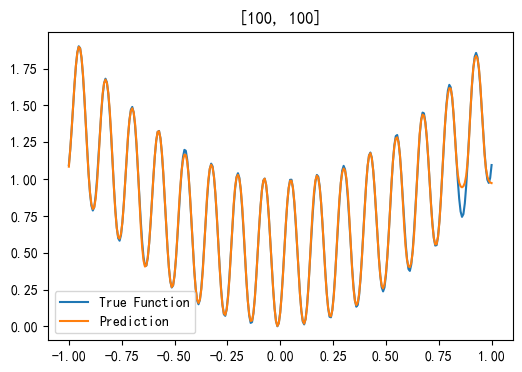

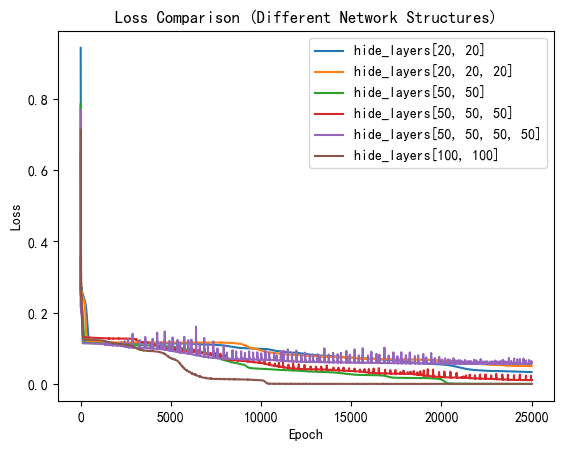

In [119]:
## ----网络结构影响----
hide_layers = [[20,20], [20,20,20], [50,50], [50,50,50],[50,50,50,50],[100,100]]
loss_dict_q2 = {}

for s in hide_layers:
    layers_q2 = [1] + s +[1]
    print(layers_q2)

    x_train_q2, y_train_q2, x_ref_q2, y_ref_q2 = generate_data()
    model_q2, loss_q2= train_model(x_train_q2, y_train_q2, layers=layers_q2)

    loss_dict_q2['hide_layers'+str(s)]=loss_q2
    x_test_q2, y_true_q2, y_pred_q2, mse_q2, mae_q2 = evaluate(model_q2)
    print('structure:', s, "MSE:", mse_q2, "MAE:", mae_q2)
    plot_result(x_test_q2, y_true_q2, y_pred_q2, str(s))

plot_loss(loss_dict_q2, title='Loss Comparison (Different Network Structures)')


## 问题3：激活函数影响

torch.Size([1, 50])
Steps: 1000, loss: 1.100e-01
Steps: 2000, loss: 1.094e-01
Steps: 3000, loss: 1.076e-01
Steps: 4000, loss: 1.016e-01
Steps: 5000, loss: 9.498e-02
Steps: 6000, loss: 9.142e-02
Steps: 7000, loss: 8.769e-02
Steps: 8000, loss: 8.488e-02
Steps: 9000, loss: 7.928e-02
Steps: 10000, loss: 7.177e-02
Steps: 11000, loss: 6.710e-02
Steps: 12000, loss: 6.438e-02
Steps: 13000, loss: 6.242e-02
Steps: 14000, loss: 6.102e-02
Steps: 15000, loss: 6.022e-02
Steps: 16000, loss: 5.918e-02
Steps: 17000, loss: 5.851e-02
Steps: 18000, loss: 5.792e-02
Steps: 19000, loss: 5.731e-02
Steps: 20000, loss: 5.677e-02
Steps: 21000, loss: 5.748e-02
Steps: 22000, loss: 5.546e-02
Steps: 23000, loss: 5.560e-02
Steps: 24000, loss: 5.447e-02
Steps: 25000, loss: 5.409e-02
structure: [100, 100] MSE: 0.06904341180118802 MAE: 0.1914012361764537


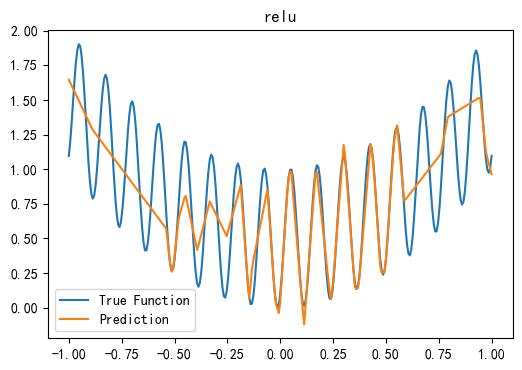

torch.Size([1, 50])
Steps: 1000, loss: 1.322e-01
Steps: 2000, loss: 1.314e-01
Steps: 3000, loss: 1.311e-01
Steps: 4000, loss: 1.308e-01
Steps: 5000, loss: 1.303e-01
Steps: 6000, loss: 1.170e-01
Steps: 7000, loss: 1.009e-01
Steps: 8000, loss: 5.544e-02
Steps: 9000, loss: 3.387e-02
Steps: 10000, loss: 2.292e-02
Steps: 11000, loss: 1.204e-02
Steps: 12000, loss: 5.462e-04
Steps: 13000, loss: 3.212e-04
Steps: 14000, loss: 1.541e-04
Steps: 15000, loss: 7.543e-05
Steps: 16000, loss: 8.037e-05
Steps: 17000, loss: 2.816e-05
Steps: 18000, loss: 2.016e-05
Steps: 19000, loss: 1.557e-05
Steps: 20000, loss: 1.265e-05
Steps: 21000, loss: 1.112e-05
Steps: 22000, loss: 1.688e-05
Steps: 23000, loss: 9.978e-06
Steps: 24000, loss: 9.662e-06
Steps: 25000, loss: 8.477e-06
structure: [100, 100] MSE: 0.00019562131629226394 MAE: 0.006546422478897024


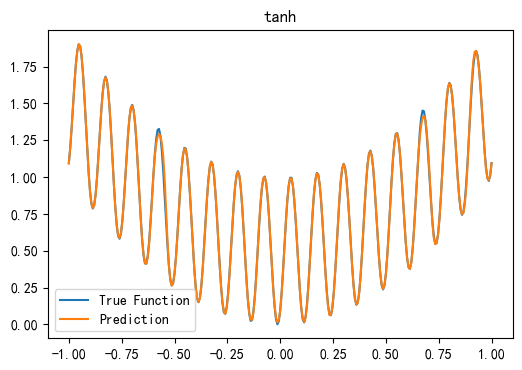

torch.Size([1, 50])
Steps: 1000, loss: 1.207e-01
Steps: 2000, loss: 1.150e-01
Steps: 3000, loss: 1.148e-01
Steps: 4000, loss: 1.147e-01
Steps: 5000, loss: 1.140e-01
Steps: 6000, loss: 1.136e-01
Steps: 7000, loss: 1.121e-01
Steps: 8000, loss: 1.098e-01
Steps: 9000, loss: 9.895e-02
Steps: 10000, loss: 9.250e-02
Steps: 11000, loss: 8.769e-02
Steps: 12000, loss: 8.527e-02
Steps: 13000, loss: 8.109e-02
Steps: 14000, loss: 7.711e-02
Steps: 15000, loss: 7.479e-02
Steps: 16000, loss: 7.015e-02
Steps: 17000, loss: 6.305e-02
Steps: 18000, loss: 5.568e-02
Steps: 19000, loss: 5.340e-02
Steps: 20000, loss: 5.122e-02
Steps: 21000, loss: 5.008e-02
Steps: 22000, loss: 4.930e-02
Steps: 23000, loss: 4.774e-02
Steps: 24000, loss: 4.350e-02
Steps: 25000, loss: 3.361e-02
structure: [100, 100] MSE: 0.038257103578780094 MAE: 0.11660589760151073


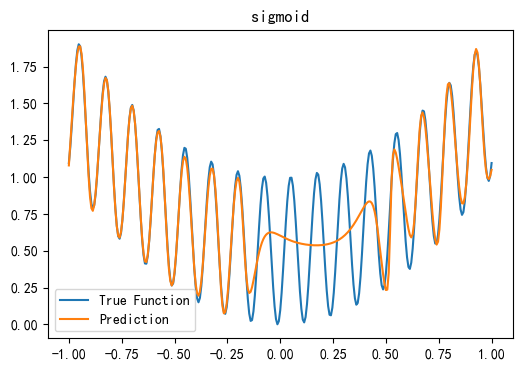

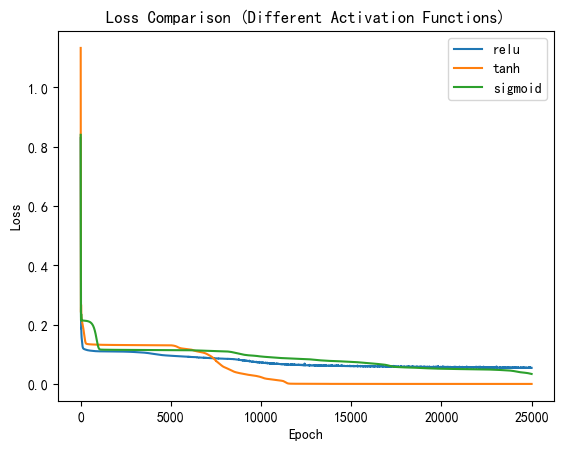

In [118]:
## ----激活函数影响----
activations = ['relu', 'tanh', 'sigmoid']
loss_dict_q3 = {}

for act in activations:
    x_train_q3, y_train_q3, x_ref_q3, y_ref_q3 = generate_data()
    model_q3, loss_q3= train_model(x_train_q3, y_train_q3, actn = act)

    loss_dict_q3[act]=loss_q3
    x_test_q3, y_true_q3, y_pred_q3, mse_q3, mae_q3 = evaluate(model_q3)
    print('structure:', s, "MSE:", mse_q3, "MAE:", mae_q3)
    plot_result(x_test_q3, y_true_q3, y_pred_q3, act)


plot_loss(loss_dict_q3, title='Loss Comparison (Different Activation Functions)')